In [18]:
import oqupy
import oqupy.operators as op
import numpy as np
import matplotlib.pyplot as plt
import time

import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
from scipy.optimize import minimize,Bounds

pt_parameters = {'tmax':20,
                 'steps':65, 
                 'dkmax':30,
                 'epsrel':10**(-7),
                 'alpha':0.1,
                 'omega_cutoff':1,                 
                 'temp':0.131}

omega_cutoff = pt_parameters['omega_cutoff']
alpha = pt_parameters['alpha']
temperature = pt_parameters['temp']
epsrel = pt_parameters['epsrel']
t_max = pt_parameters['tmax']
# dt = 1./omega_cutoff/np.sqrt(3)
num_steps = pt_parameters['steps']
dt = t_max/num_steps
dkmax = pt_parameters['dkmax']

t_list = np.linspace(0,t_max,num_steps+1)

tcut=25

import oqupy as oqupy
from oqupy.iTEBD_TEMPO_useoqupybath import iTEBD_TEMPO_oqupy
from oqupy.process_tensor import TTInvariantProcessTensor
from oqupy.tti_tempo import TTITempo
from oqupy.tti_tempo import TTITempoCounting
import numpy as np
import matplotlib.pyplot as plt

# Dynamics calculations convergence

# spectral density (without cutoff)
def j(w):
    return 2*alpha*w

correlations = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1.00001,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)
correlations_eta = oqupy.PowerLawSD(alpha=alpha,
                                zeta=1,
                                cutoff=omega_cutoff,
                                cutoff_type='exponential',
                                temperature=temperature)

bath = oqupy.Bath(op.sigma("z")/2.0, correlations)
parameters=oqupy.TempoParameters(dt=dt,epsrel=epsrel,dkmax=dkmax)

u=0.1

correlationscf=oqupy.bath_correlations.CustomCountingSD(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)
correlationscf_eta=oqupy.bath_correlations.CustomCountingSD_analytical(j_function=j,cutoff=omega_cutoff,u=u,
                                                 cutoff_type='exponential',temperature=temperature)



Text(0.5, 1.0, 'Unmarked')

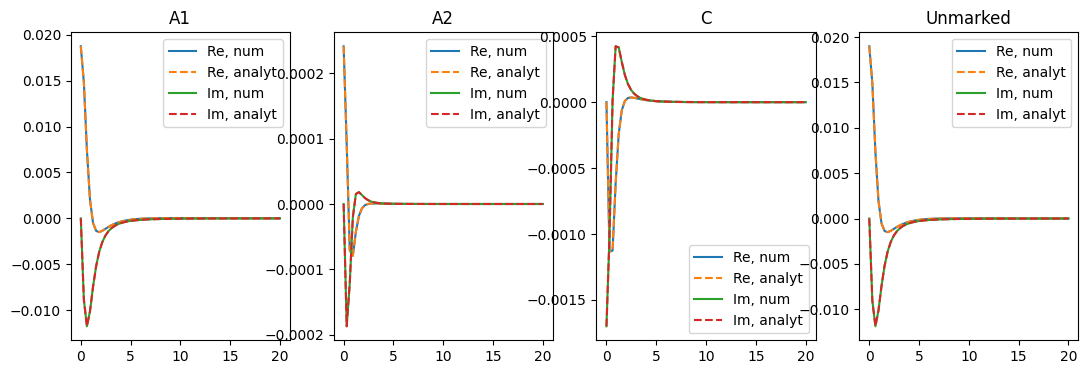

In [21]:
# A1 correlation integral

fig,axs = plt.subplots(1,4, figsize = (13,4))

res = [correlationscf.correlation_2d_integral_marked(delta=dt,time_1=tau,shape='square',which_corr='A1') for tau in t_list]
res_eta = [correlationscf_eta.correlation_2d_integral_marked_eta(delta=dt,time_1=tau,shape='square',which_corr='A1') for tau in t_list]

axs[0].plot(t_list,np.real(res), label = 'Re, num')
axs[0].plot(t_list,np.real(res_eta), linestyle = 'dashed', label = 'Re, analyt')
axs[0].plot(t_list,np.imag(res), label = 'Im, num')
axs[0].plot(t_list,np.imag(res_eta), linestyle = 'dashed', label = 'Im, analyt')
axs[0].legend()
axs[0].set_title('A1')

res = [correlationscf.correlation_2d_integral_marked(delta=dt,time_1=tau,shape='square',which_corr='A2') for tau in t_list]
res_eta = [correlationscf_eta.correlation_2d_integral_marked_eta(delta=dt,time_1=tau,shape='square',which_corr='A2') for tau in t_list]

axs[1].plot(t_list,np.real(res), label = 'Re, num')
axs[1].plot(t_list,np.real(res_eta), linestyle = 'dashed', label = 'Re, analyt')
axs[1].plot(t_list,np.imag(res), label = 'Im, num')
axs[1].plot(t_list,np.imag(res_eta), linestyle = 'dashed', label = 'Im, analyt')
axs[1].legend()
axs[1].set_title('A2')

res = [correlationscf.correlation_2d_integral_marked(delta=dt,time_1=tau,shape='square',which_corr='C') for tau in t_list]
res_eta = [correlationscf_eta.correlation_2d_integral_marked_eta(delta=dt,time_1=tau,shape='square',which_corr='C') for tau in t_list]

axs[2].plot(t_list,np.real(res), label = 'Re, num')
axs[2].plot(t_list,np.real(res_eta), linestyle = 'dashed', label = 'Re, analyt')
axs[2].plot(t_list,np.imag(res), label = 'Im, num')
axs[2].plot(t_list,np.imag(res_eta), linestyle = 'dashed', label = 'Im, analyt')
axs[2].legend()
axs[2].set_title('C')

res = [correlations.correlation_2d_integral(delta=dt,time_1=tau,shape='square') for tau in t_list]
res_eta = [correlations_eta.correlation_2d_integral(delta=dt,time_1=tau,shape='square') for tau in t_list]

axs[3].plot(t_list,np.real(res), label = 'Re, num')
axs[3].plot(t_list,np.real(res_eta), linestyle = 'dashed', label = 'Re, analyt')
axs[3].plot(t_list,np.imag(res), label = 'Im, num')
axs[3].plot(t_list,np.imag(res_eta), linestyle = 'dashed', label = 'Im, analyt')
axs[3].legend()
axs[3].set_title('Unmarked')

In [5]:
eta = correlationscfeta.correlation_2d_integral_marked_eta(delta=dt,time_1=tau,shape='square',which_corr='A1')
num = correlationscf.correlation_2d_integral_marked(delta=dt,time_1=tau,shape='square',which_corr='A1')
num_old = correlationscf.correlation_2d_integral_marked_old(delta=dt,time_1=tau,shape='square',which_corr='A1')
print([eta, num, num_old])

eta = correlationscfeta.correlation_2d_integral_marked_eta(delta=dt,time_1=tau,shape='square',which_corr='A2')
num = correlationscf.correlation_2d_integral_marked(delta=dt,time_1=tau,shape='square',which_corr='A2')
num_old = correlationscf.correlation_2d_integral_marked_old(delta=dt,time_1=tau,shape='square',which_corr='A2')
print([eta, num, num_old])

eta = correlationscfeta.correlation_2d_integral_marked_eta(delta=dt,time_1=tau,shape='square',which_corr='C')
num = correlationscf.correlation_2d_integral_marked(delta=dt,time_1=tau,shape='square',which_corr='C')
num_old = correlationscf.correlation_2d_integral_marked_old(delta=dt,time_1=tau,shape='square',which_corr='C')
print([eta, num, num_old])

[(-0.0007500263608587465-0.0010738109690592301j), (-0.0007500263706464804-0.0010738109811308126j), (-0.0007500263609398513-0.0010738109691049626j)]
[(8.106700835619485e-07+2.5070365792245752e-06j), (8.106617376949983e-07+2.5070123062283536e-06j), (8.106700839234362e-07+2.5070365792409247e-06j)]
[(2.8034640236852815e-05+4.585889280133218e-05j), (2.8034622913839457e-05+4.585890245922858e-05j), (2.8034640322466832e-05+4.585889271434418e-05j)]
